In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import accuracy_score,mean_squared_error

In [2]:
df = pd.read_csv("C:\\Users\\Rudra\\Downloads\\Tele_dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.drop(columns='customerID',inplace=True)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = df['TotalCharges'].astype(float)
df[df['TotalCharges'].isnull()]
df['TotalCharges'] = (
    df['TotalCharges']
    .fillna(0)
)

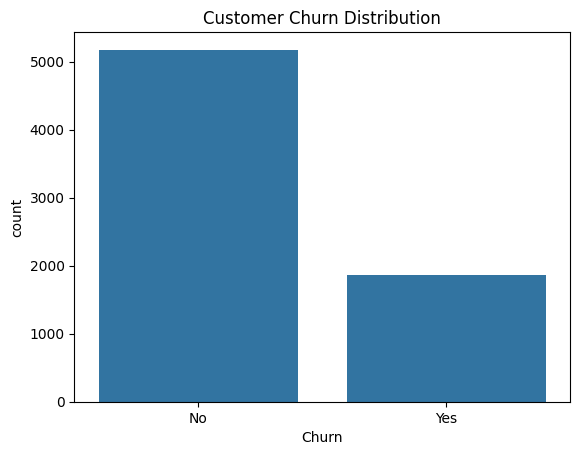

In [9]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

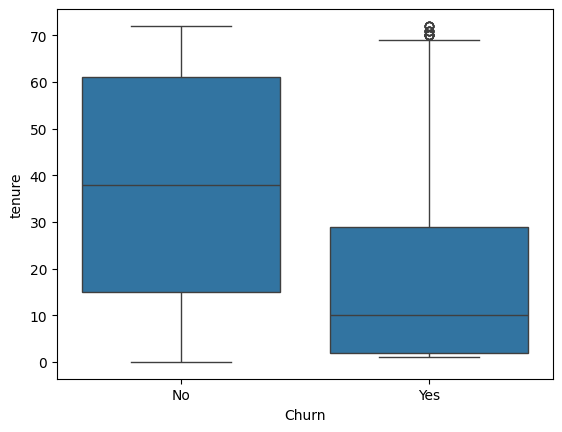

In [10]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.show()

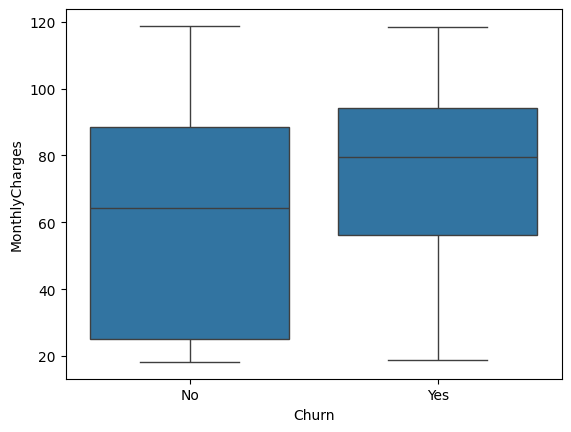

In [11]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

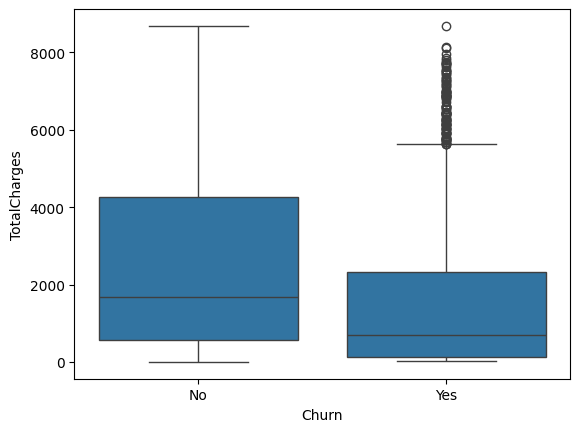

In [12]:
sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.show()

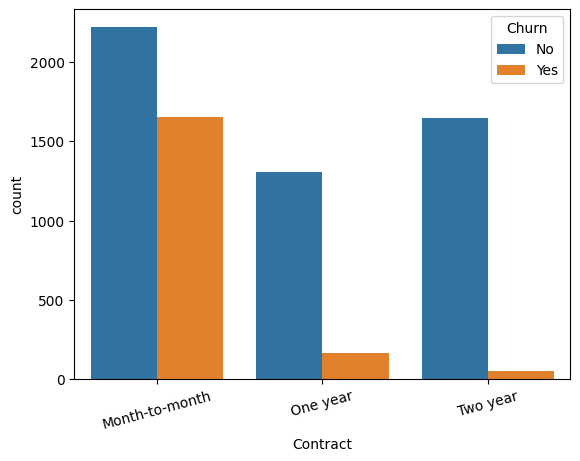

In [13]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=15)
plt.show()

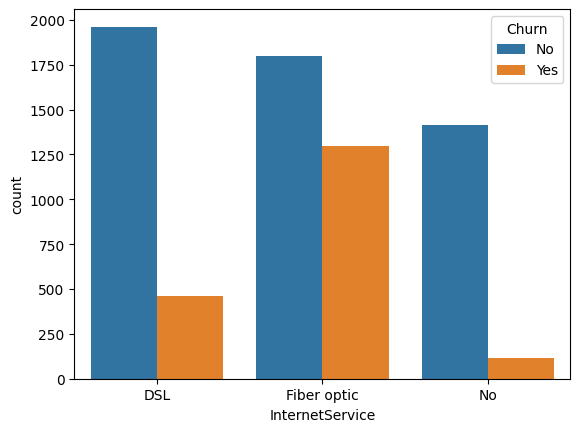

In [14]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

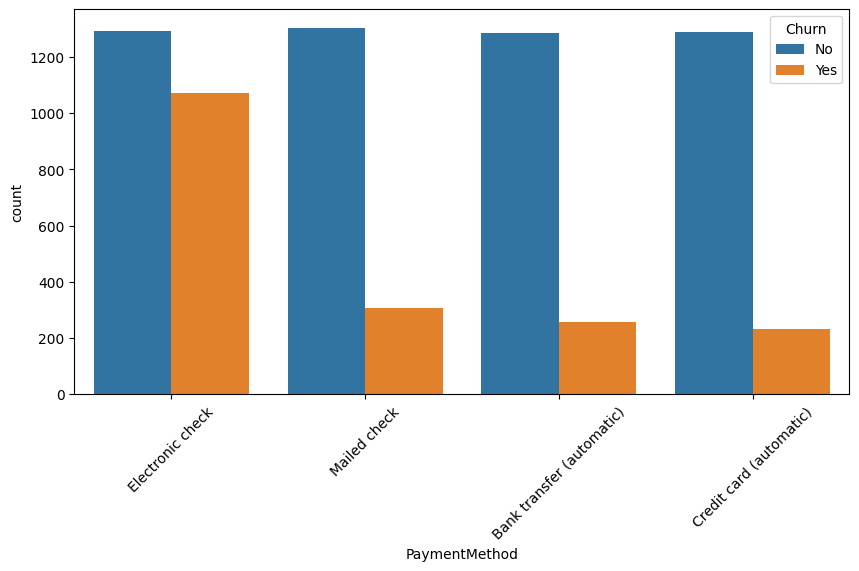

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)
plt.show()

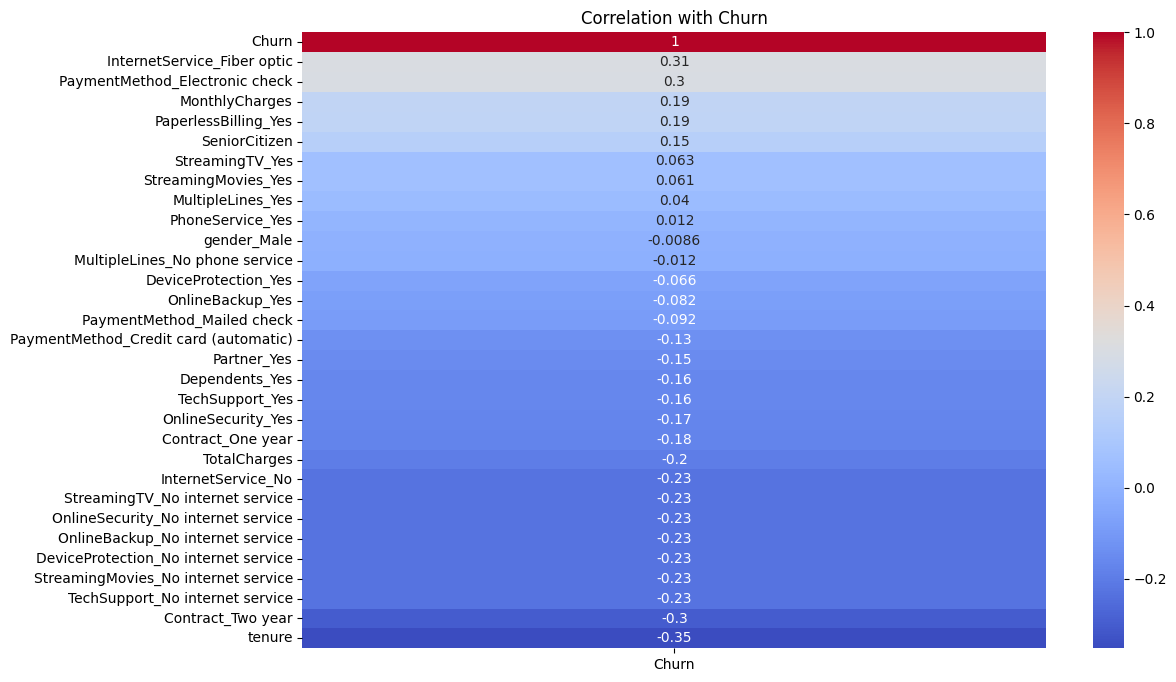

In [16]:
plt.figure(figsize=(12,8))

corr_df = df.copy()

corr_df['Churn'] = corr_df['Churn'].map({'No':0,'Yes':1})

corr_df = pd.get_dummies(corr_df, drop_first=True)

corr_matrix = corr_df.corr()

sns.heatmap(
    corr_matrix[['Churn']]
    .sort_values(by='Churn', ascending=False),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation with Churn")
plt.show()

In [63]:

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [64]:
X=df.drop(['Churn'],axis=1)
y=df['Churn']

In [40]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
numerical_cat= X_train.select_dtypes(include=['float64','int64']).columns.tolist()
categorical_cat = X_train.select_dtypes(include='str').columns.tolist()

In [67]:
# Separate pipelines to ensure everything ends up scaled correctly
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV ,StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

numeric_transformer = StandardScaler()
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop='first')),
    ('scaler', StandardScaler(with_mean=False)) # <--- UPGRADE 2: Scaled safely without breaking sparsity
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cat),
        ('cat', categorical_transformer, categorical_cat)
    ]
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # UPGRADE 1: Switched to 'saga' solver to properly handle l1/l2 combos at scale
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, solver='saga', max_iter=5000))
])

# ==========================================
# 3. UPGRADED HYPERPARAMETER GRID
# ==========================================
param_grid = {
    'classifier__C': np.logspace(-3, 2, 10),  
    'classifier__l1_ratio': [1.0, 0.0]               
}
# ==========================================
# 4. GRID SEARCH WITH CROSS-VALIDATION
# ==========================================
cv= StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator=full_pipeline, 
    param_grid=param_grid, 
    cv=cv,                
    scoring='f1',        
    n_jobs=-1,           
    verbose=1
)

# ==========================================
# 5. FIT AND PREDICT
# ==========================================
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)

# ==========================================
# 6. RESULTS
# ==========================================
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}\n")
print("================ TEST SET EVALUATION ================")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'classifier__C': np.float64(2.1544346900318843), 'classifier__l1_ratio': 0.0}
Best Cross-Validation F1-Score: 0.6293

================ TEST SET EVALUATION ================
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [70]:
# Separate pipelines to ensure everything ends up scaled correctly
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV ,StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

numeric_transformer = StandardScaler()
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop='first')),
    ('scaler', StandardScaler(with_mean=False)) # <--- UPGRADE 2: Scaled safely without breaking sparsity
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cat),
        ('cat', categorical_transformer, categorical_cat)
    ]
)

full_pipeline = Pipeline(steps=[
   ('preprocessor', preprocessor),
   
    ('classifier', RandomForestClassifier(random_state=42,class_weight='balanced_subsample', n_jobs=-1))
])

# ==========================================
# 3. UPGRADED HYPERPARAMETER GRID
# ==========================================
param_grid = {
    'classifier__n_estimators': [100, 200, 300],      # How many trees?
    'classifier__max_depth': [None, 10, 20, 30],      # How deep can they grow?
    'classifier__min_samples_split': [2, 5, 10]       # How specific can the rules get?
}
# ==========================================
# 4. GRID SEARCH WITH CROSS-VALIDATION
# ==========================================
cv= StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator=full_pipeline, 
    param_grid=param_grid, 
    cv=cv,                
    scoring='f1',        
    n_jobs=-1,           
    verbose=1
)

# ==========================================
# 5. FIT AND PREDICT
# ==========================================
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)

# ==========================================
# 6. RESULTS
# ==========================================
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}\n")
print("================ TEST SET EVALUATION ================")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best Cross-Validation F1-Score: 0.6399

================ TEST SET EVALUATION ================
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [71]:
# Separate pipelines to ensure everything ends up scaled correctly
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV ,StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report ,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

numeric_transformer = StandardScaler()
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop='first')),
    ('scaler', StandardScaler(with_mean=False)) # <--- UPGRADE 2: Scaled safely without breaking sparsity
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cat),
        ('cat', categorical_transformer, categorical_cat)
    ]
)

full_pipeline = Pipeline(steps=[
   ('preprocessor', preprocessor),
   
  ('classifier', xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'))
])

# ==========================================
# 3. UPGRADED HYPERPARAMETER GRID
# ==========================================
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__scale_pos_weight': [1, 3, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}
# ==========================================
# 4. GRID SEARCH WITH CROSS-VALIDATION
# ==========================================
cv= StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
random_search = RandomizedSearchCV(
    estimator=full_pipeline, 
    param_distributions=param_grid, 
    n_iter=50,             # Tests 50 random combinations to save time
    cv=cv,                
    scoring='roc_auc',         
    n_jobs=-1,             # Uses all available CPU cores
    verbose=1,             # Prints progress to the console
    random_state=42
)

# ==========================================
# 5. FIT AND PREDICT
# ==========================================
random_search.fit(X_train, y_train)
y_pred = random_search.predict(X_test)
y_pred_proba = random_search.predict_proba(X_test)[:, 1]
# ==========================================
# 6. RESULTS
# ==========================================
print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {random_search.best_score_:.4f}\n")
print(f"Test Set ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print("================ TEST SET EVALUATION ================")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 5, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
Best Cross-Validation F1-Score: 0.8495

Test Set ROC-AUC: 0.8451

================ TEST SET EVALUATION ================
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1035
           1       0.46      0.87      0.60       374

    accuracy                           0.69      1409
   macro avg       0.69      0.75      0.67      1409
weighted avg       0.81      0.69      0.71      1409



In [72]:
from sklearn.metrics import precision_recall_curve
import numpy as np
y_pred_proba = random_search.predict_proba(X_test)[:, 1] 

# 2. Calculate precision and recall for every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 3. Calculate the F1-Score for every threshold
# (We add a tiny number like 1e-10 to prevent dividing by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 4. Find the threshold that gives the absolute highest F1-Score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"================ THRESHOLD OPTIMIZATION ================")
print(f"Default Threshold: 0.50")
print(f"Optimal Threshold: {best_threshold:.4f}\n")

# 5. Apply the new threshold to our predictions
# If probability >= best_threshold, predict 1 (Churn), else 0 (Stay)
y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

print("================ OPTIMIZED XGBOOST EVALUATION ================")
print(classification_report(y_test, y_pred_optimized))


================ THRESHOLD OPTIMIZATION ================
Default Threshold: 0.50
Optimal Threshold: 0.7438

================ OPTIMIZED XGBOOST EVALUATION ================
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1035
           1       0.58      0.71      0.64       374

    accuracy                           0.79      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.79      0.79      1409



In [73]:
import pickle

# 1. Grab the winning pipeline from your randomized search
best_pipeline = random_search.best_estimator_

# 2. Open a new file in "write-binary" ('wb') mode and save it
with open('xgboost_churn_pipeline.pkl', 'wb') as file:
    pickle.dump(best_pipeline, file)

print("Pipeline successfully saved to 'xgboost_churn_pipeline.pkl'!")

Pipeline successfully saved to 'xgboost_churn_pipeline.pkl'!
